In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.info()
data.columns

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [4]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

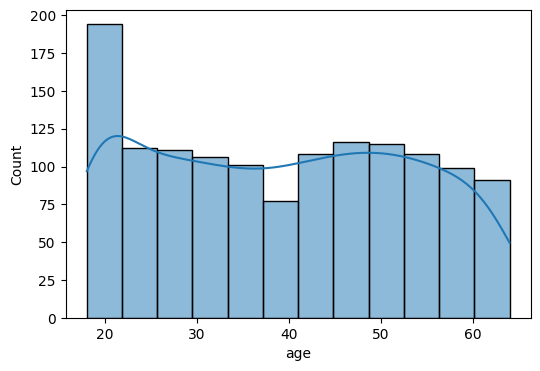

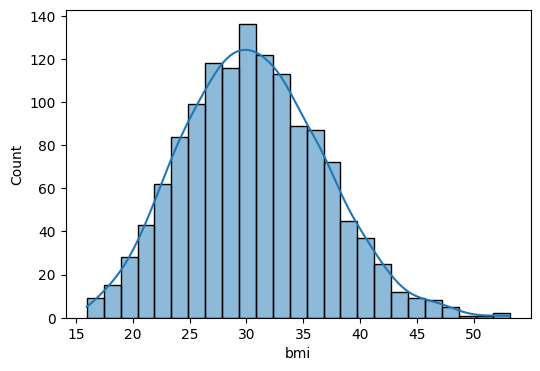

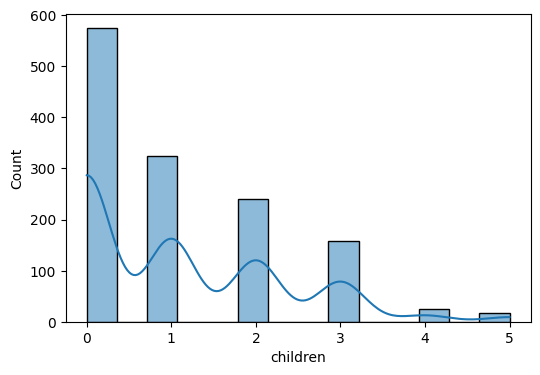

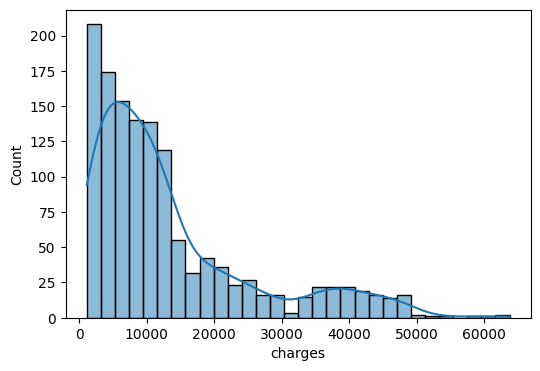

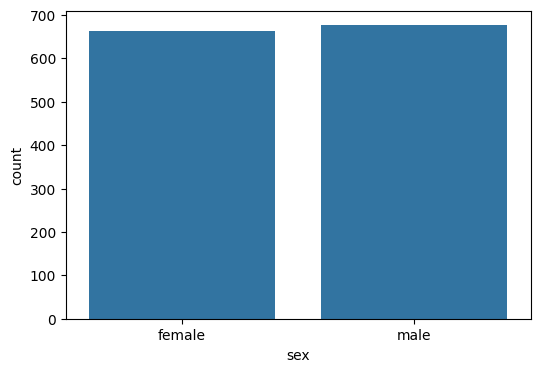

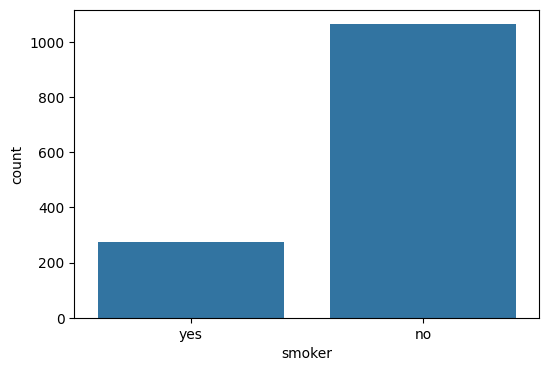

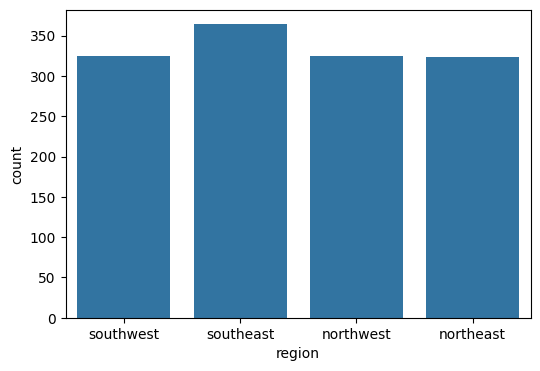

In [5]:
dfcol = ['age', 'bmi', 'children', 'charges']
dfcat = ['sex', 'smoker', 'region']
for col in dfcol :
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde = True)
for colu in dfcat :
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[colu])    

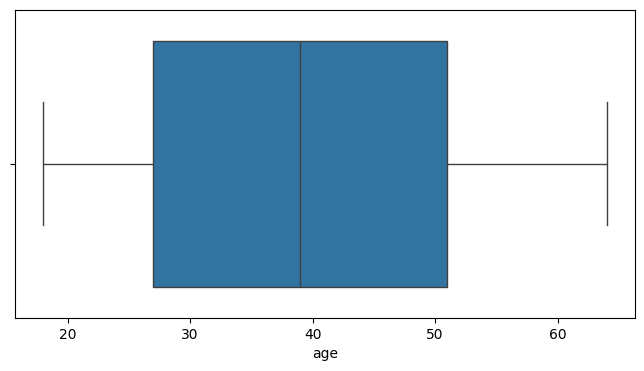

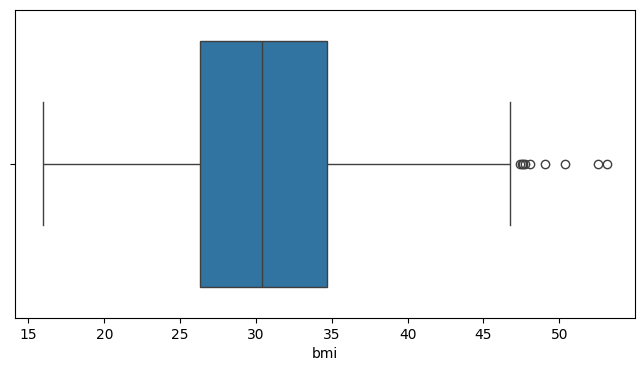

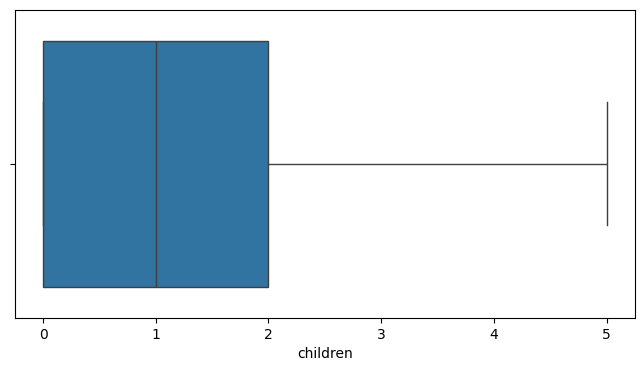

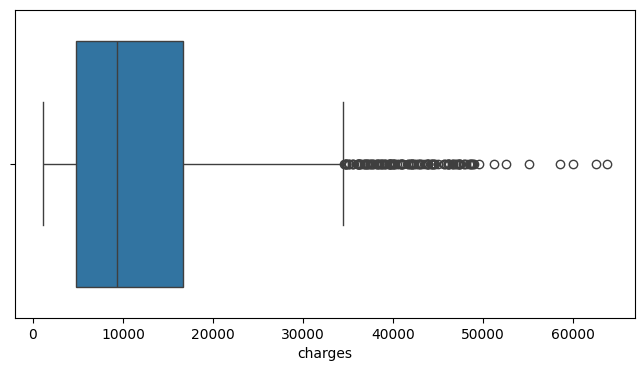

In [6]:
for i in dfcol:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[i])


In [7]:
dataframe = pd.DataFrame(data)
dataframe.corr(numeric_only=True)


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

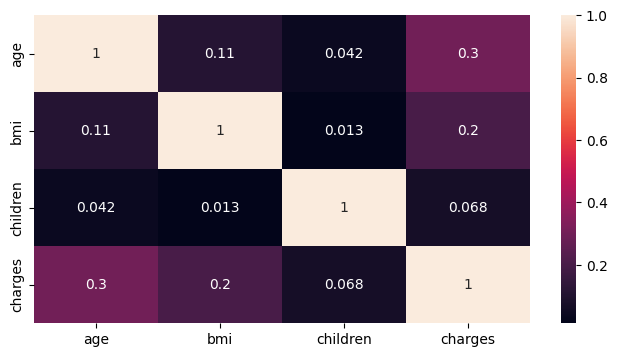

In [8]:
plt.figure(figsize=(8,4))
sns.heatmap(data.corr(numeric_only=True), annot=True)

In [9]:
dataframe.shape

(1338, 7)

In [10]:
dataframe = dataframe.drop_duplicates()

In [11]:
dataframe.shape

(1337, 7)

In [12]:
dataframe.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [13]:
import sklearn
sklearn.set_config(transform_output="pandas")

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataframe['sex']=le.fit_transform(dataframe['sex'])

In [15]:
dataframe.dtypes


age           int64
sex           int64
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [16]:
datar = dataframe.drop(columns=['region'])

In [17]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(sparse_output=False)
dataframe = oh.fit_transform(dataframe[['region']])

In [18]:
dataframe

,region_northeast,region_northwest,region_southeast,region_southwest
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
1333,0.0,1.0,0.0,0.0
1334,1.0,0.0,0.0,0.0
1335,0.0,0.0,1.0,0.0
1336,0.0,0.0,0.0,1.0


In [19]:
datar = pd.concat([dataframe, datar], axis =1)

In [20]:
datar

,region_northeast,region_northwest,region_southeast,region_southwest,age,sex,bmi,children,smoker,charges
0,0.0,0.0,0.0,1.0,19,0,27.900,0,yes,16884.92400
1,0.0,0.0,1.0,0.0,18,1,33.770,1,no,1725.55230
2,0.0,0.0,1.0,0.0,28,1,33.000,3,no,4449.46200
3,0.0,1.0,0.0,0.0,33,1,22.705,0,no,21984.47061
4,0.0,1.0,0.0,0.0,32,1,28.880,0,no,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,0.0,1.0,0.0,0.0,50,1,30.970,3,no,10600.54830
1334,1.0,0.0,0.0,0.0,18,0,31.920,0,no,2205.98080
1335,0.0,0.0,1.0,0.0,18,0,36.850,0,no,1629.83350
1336,0.0,0.0,0.0,1.0,21,0,25.800,0,no,2007.94500


In [21]:
datar['category']=pd.cut(
    datar['bmi'], 
    bins=[0, 18.5, 25, 29.9, float('inf')],
    labels=['skinny', 'normal', 'fat', 'obese']
)

In [22]:
datar

,region_northeast,region_northwest,region_southeast,region_southwest,age,sex,bmi,children,smoker,charges,category
0,0.0,0.0,0.0,1.0,19,0,27.900,0,yes,16884.92400,fat
1,0.0,0.0,1.0,0.0,18,1,33.770,1,no,1725.55230,obese
2,0.0,0.0,1.0,0.0,28,1,33.000,3,no,4449.46200,obese
3,0.0,1.0,0.0,0.0,33,1,22.705,0,no,21984.47061,normal
4,0.0,1.0,0.0,0.0,32,1,28.880,0,no,3866.85520,fat
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.0,1.0,0.0,0.0,50,1,30.970,3,no,10600.54830,obese
1334,1.0,0.0,0.0,0.0,18,0,31.920,0,no,2205.98080,obese
1335,0.0,0.0,1.0,0.0,18,0,36.850,0,no,1629.83350,obese
1336,0.0,0.0,0.0,1.0,21,0,25.800,0,no,2007.94500,fat


In [23]:
datar=pd.get_dummies(datar, columns=['category'], drop_first=True)

In [24]:
datar['smoker'] = le.fit_transform(datar['smoker'])

In [25]:
datar=datar.astype(int)
datar

,region_northeast,region_northwest,region_southeast,region_southwest,age,sex,bmi,children,smoker,charges,category_normal,category_fat,category_obese
0,0,0,0,1,19,0,27,0,1,16884,0,1,0
1,0,0,1,0,18,1,33,1,0,1725,0,0,1
2,0,0,1,0,28,1,33,3,0,4449,0,0,1
3,0,1,0,0,33,1,22,0,0,21984,1,0,0
4,0,1,0,0,32,1,28,0,0,3866,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0,1,0,0,50,1,30,3,0,10600,0,0,1
1334,1,0,0,0,18,0,31,0,0,2205,0,0,1
1335,0,0,1,0,18,0,36,0,0,1629,0,0,1
1336,0,0,0,1,21,0,25,0,0,2007,0,1,0


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols = ['age', 'bmi', 'children']
datar[cols]= scaler.fit_transform(datar[cols])
datar

,region_northeast,region_northwest,region_southeast,region_southwest,age,sex,bmi,children,smoker,charges,category_normal,category_fat,category_obese
0,0,0,0,1,-1.440418,0,-0.517949,-0.909234,1,16884,0,1,0
1,0,0,1,0,-1.511647,1,0.462463,-0.079442,0,1725,0,0,1
2,0,0,1,0,-0.799350,1,0.462463,1.580143,0,4449,0,0,1
3,0,1,0,0,-0.443201,1,-1.334960,-0.909234,0,21984,1,0,0
4,0,1,0,0,-0.514431,1,-0.354547,-0.909234,0,3866,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0,1,0,0,0.767704,1,-0.027743,1.580143,0,10600,0,0,1
1334,1,0,0,0,-1.511647,0,0.135659,-0.909234,0,2205,0,0,1
1335,0,0,1,0,-1.511647,0,0.952670,-0.909234,0,1629,0,0,1
1336,0,0,0,1,-1.297958,0,-0.844753,-0.909234,0,2007,0,1,0


<Axes: >

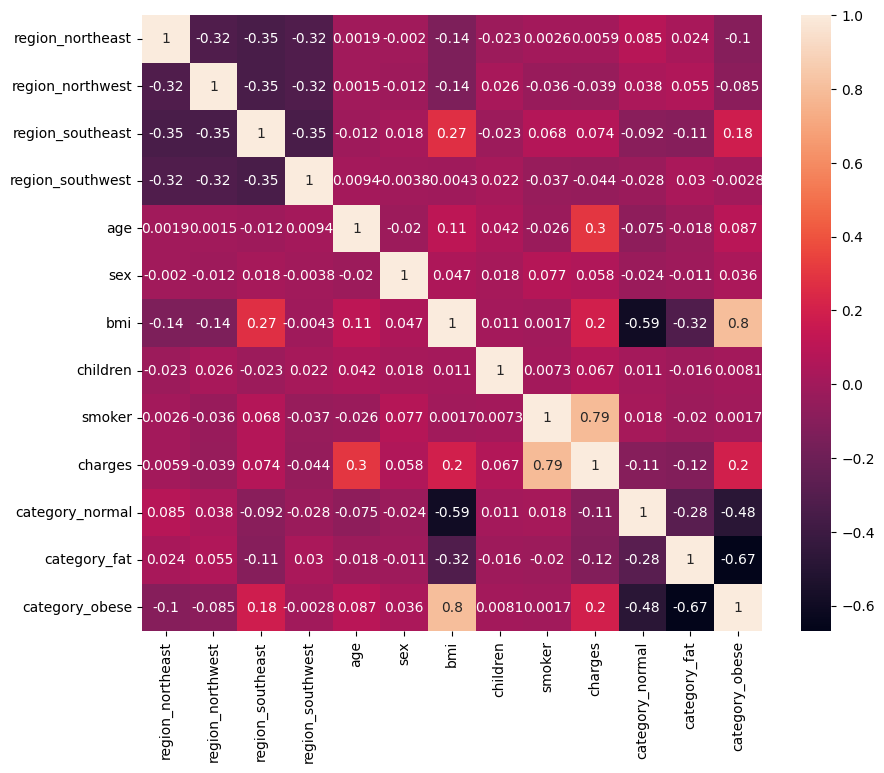

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(datar.corr(numeric_only=True), annot=True)

In [28]:
datar.columns

Index(['region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'age', 'sex', 'bmi', 'children', 'smoker',
       'charges', 'category_normal', 'category_fat', 'category_obese'],
      dtype='str')

In [29]:
from scipy.stats import chi2_contingency
datar['bins']=pd.qcut(datar['charges'], q=4, labels=False)

target_col = 'bins'
categorical_features = ['region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'age', 'sex', 'bmi', 'children', 'smoker', 'category_normal', 'category_fat', 'category_obese'] 

features_to_keep = []
features_to_drop = []

print(f"--- Chi-Square Feature Selection for Target: '{target_col}' ---\n")

for feature in categorical_features:

    contingency_table = pd.crosstab(datar[feature], datar[target_col])
    
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    if p_value < 0.05:
        print(f"✅ KEEP  | {feature:<15} | p-value: {p_value:.4f}")
        features_to_keep.append(feature)
    else:
        print(f"❌ DROP  | {feature:<15} | p-value: {p_value:.4f}")
        features_to_drop.append(feature)

print("\n--- Summary ---")
print(f"Total features to keep: {len(features_to_keep)}")
print(f"Total features to drop: {len(features_to_drop)}")


--- Chi-Square Feature Selection for Target: 'bins' ---

❌ DROP  | region_northeast | p-value: 0.0921
❌ DROP  | region_northwest | p-value: 0.7688
✅ KEEP  | region_southeast | p-value: 0.0011
❌ DROP  | region_southwest | p-value: 0.1652
✅ KEEP  | age             | p-value: 0.0000
✅ KEEP  | sex             | p-value: 0.0165
✅ KEEP  | bmi             | p-value: 0.0173
✅ KEEP  | children        | p-value: 0.0000
✅ KEEP  | smoker          | p-value: 0.0000
❌ DROP  | category_normal | p-value: 0.3073
❌ DROP  | category_fat    | p-value: 0.3139
❌ DROP  | category_obese  | p-value: 0.0537

--- Summary ---
Total features to keep: 6
Total features to drop: 6


In [35]:
dffinal=datar[['region_southeast', 'age', 'sex', 'bmi', 'region_southeast', 'children', 'smoker', 'charges']]

In [36]:
dffinal

,region_southeast,age,sex,bmi,region_southeast,children,smoker,charges
0,0,-1.440418,0,-0.517949,0,-0.909234,1,16884
1,1,-1.511647,1,0.462463,1,-0.079442,0,1725
2,1,-0.799350,1,0.462463,1,1.580143,0,4449
3,0,-0.443201,1,-1.334960,0,-0.909234,0,21984
4,0,-0.514431,1,-0.354547,0,-0.909234,0,3866
...,...,...,...,...,...,...,...,...
1333,0,0.767704,1,-0.027743,0,1.580143,0,10600
1334,0,-1.511647,0,0.135659,0,-0.909234,0,2205
1335,1,-1.511647,0,0.952670,1,-0.909234,0,1629
1336,0,-1.297958,0,-0.844753,0,-0.909234,0,2007


In [32]:
from sklearn.model_selection import train_test_split


In [37]:
y = dffinal['charges']
x = dffinal.drop('charges', axis =1)

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.20, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred = model.predict(x_test)

In [48]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 is", r2)

n = x_test.shape[0]
p = x_test.shape[1]

adjr2 = 1-(((1-r2)*(n-1))/(n-p-1))
print("adj R2 is", adjr2)


R2 is 0.8053741941169438
adj R2 is 0.8001342685739384
